# Reflection / Glare Removal Pipeline for Fingernail ROI Images

Goal: remove small reflection glares while preserving nail color quality for anemia prediction.

Core rule:
- **Small glare** → inpaint
- **Medium / large glare** → soften only
- **Too much glare** → mark as unusable / warning, do not fake the nail color

Outputs:
- processed PNG images
- glare masks
- before/after previews
- `reflection_report.csv`
- `reflection_review_contact_sheet.png`

This notebook does **not resize** images and saves processed outputs as **PNG** to avoid quality loss.


In [1]:
# Install dependencies if needed
# In Colab, uncomment:
# !pip install opencv-python pillow pandas tqdm matplotlib

import os
import shutil
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
from PIL import Image, ImageOps, ImageDraw
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

print("Ready.")

/opt/anaconda3/envs/nail_preprocess/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ready.


## 1. Configure paths

Set `INPUT_DIR` to the folder containing your cropped nail ROI images.

Recommended input: output from your ROI scaling pipeline.


In [2]:
# ===== USER SETTINGS =====

INPUT_DIR = Path('/Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/brighten/usable_nail_crops_roi102_flat_images_brightened')   # change this
OUTPUT_DIR = Path("/Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/glare/usable_nail_crops_roi102_flat_images_brightened_reflection_removed_output")  # change this

# Save organization
PROCESSED_DIR = OUTPUT_DIR / "processed_png"
MASK_DIR = OUTPUT_DIR / "masks"
PREVIEW_DIR = OUTPUT_DIR / "previews"
UNUSABLE_DIR = OUTPUT_DIR / "unusable_too_much_glare"

# Supported inputs; all processed outputs are saved as PNG
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

# Glare thresholds
FIXED_V_THRESH = 220
FIXED_S_THRESH = 60

ADAPTIVE_PERCENTILE = 97
ADAPTIVE_S_THRESH = 80

# Method thresholds, percent of foreground/nail area
SMALL_GLARE_PERCENT = 5.0      # <= this: inpaint
LARGE_GLARE_PERCENT = 15.0     # <= this: soften; > this: mark unusable

# Mask post-processing
DILATE_KERNEL_SIZE = 3
DILATE_ITERATIONS = 1

# Inpainting settings
INPAINT_RADIUS = 3
INPAINT_METHOD = cv2.INPAINT_TELEA  # cv2.INPAINT_NS is another option

# Softening settings
SOFTEN_BLEND_STRENGTH = 0.65
# Higher means stronger replacement of glare brightness by local/nearby estimate.

# Preview settings
MAKE_PREVIEWS = True
MAKE_CONTACT_SHEET = True
CONTACT_SHEET_MAX_IMAGES = 60

for d in [PROCESSED_DIR, MASK_DIR, PREVIEW_DIR, UNUSABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Input :", INPUT_DIR)
print("Output:", OUTPUT_DIR)

Input : /Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/brighten/usable_nail_crops_roi102_flat_images_brightened
Output: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/glare/usable_nail_crops_roi102_flat_images_brightened_reflection_removed_output


## 2. Helper functions

Main idea:
1. Preserve alpha if the input PNG has transparency.
2. Build a foreground mask so background is not processed.
3. Detect glare using both fixed HSV and adaptive HSV rules.
4. Decide method from glare area percentage.


In [3]:
def list_images(input_dir: Path):
    return sorted([p for p in input_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTS])


def read_image_preserve_alpha(path: Path):
    """
    Returns:
        bgr: uint8 BGR image, HxWx3
        alpha: uint8 alpha channel or None
        original_mode: PIL mode string
    """
    pil = Image.open(path)
    original_mode = pil.mode
    pil = ImageOps.exif_transpose(pil)

    if pil.mode in ("RGBA", "LA"):
        rgba = pil.convert("RGBA")
        arr = np.array(rgba)
        rgb = arr[:, :, :3]
        alpha = arr[:, :, 3]
    else:
        rgb = np.array(pil.convert("RGB"))
        alpha = None

    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    return bgr, alpha, original_mode


def make_foreground_mask(bgr, alpha=None):
    """
    Foreground/nail mask.
    If alpha exists, use alpha > 0.
    Otherwise, treat near-black background as background.
    """
    if alpha is not None:
        fg = alpha > 0
    else:
        gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
        # Conservative: ignore pure/near black padding only.
        fg = gray > 5

    # Remove tiny holes/noise
    fg_u8 = (fg.astype(np.uint8) * 255)
    kernel = np.ones((3, 3), np.uint8)
    fg_u8 = cv2.morphologyEx(fg_u8, cv2.MORPH_CLOSE, kernel, iterations=1)
    return fg_u8 > 0


def detect_glare_mask(bgr, foreground_mask):
    """
    HSV glare detection:
        fixed: V > 220 and S < 60
        adaptive: V > percentile(V, 97) and S < 80
    Only inside foreground.
    """
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    fg = foreground_mask.astype(bool)
    if fg.sum() == 0:
        return np.zeros(fg.shape, dtype=np.uint8), {
            "adaptive_v_threshold": np.nan,
            "fixed_pixels": 0,
            "adaptive_pixels": 0
        }

    v_fg = v[fg]
    adaptive_v = np.percentile(v_fg, ADAPTIVE_PERCENTILE)

    fixed_mask = (v > FIXED_V_THRESH) & (s < FIXED_S_THRESH) & fg
    adaptive_mask = (v > adaptive_v) & (s < ADAPTIVE_S_THRESH) & fg

    glare = fixed_mask | adaptive_mask

    # Dilate slightly so the border of glare is also repaired
    if DILATE_KERNEL_SIZE > 0 and DILATE_ITERATIONS > 0:
        kernel = np.ones((DILATE_KERNEL_SIZE, DILATE_KERNEL_SIZE), np.uint8)
        glare_u8 = cv2.dilate((glare.astype(np.uint8) * 255), kernel, iterations=DILATE_ITERATIONS)
        glare = (glare_u8 > 0) & fg

    return (glare.astype(np.uint8) * 255), {
        "adaptive_v_threshold": float(adaptive_v),
        "fixed_pixels": int(fixed_mask.sum()),
        "adaptive_pixels": int(adaptive_mask.sum())
    }


def glare_percent(mask_u8, foreground_mask):
    fg_area = int(foreground_mask.sum())
    glare_area = int((mask_u8 > 0).sum())
    if fg_area == 0:
        return 0.0, glare_area, fg_area
    return 100.0 * glare_area / fg_area, glare_area, fg_area


def choose_method(glare_pct):
    if glare_pct <= 0:
        return "none", "ok_no_glare"
    if glare_pct <= SMALL_GLARE_PERCENT:
        return "inpaint", "ok"
    if glare_pct <= LARGE_GLARE_PERCENT:
        return "soften", "warning_large_glare_softened"
    return "copy_original", "unusable_too_much_glare"


def inpaint_glare(bgr, mask_u8):
    return cv2.inpaint(bgr, mask_u8, INPAINT_RADIUS, INPAINT_METHOD)


def soften_glare(bgr, mask_u8, foreground_mask):
    """
    Safer than full inpainting for large glare:
    reduce brightness in glare regions using a blurred local estimate,
    while preserving some original color/texture.
    """
    mask = mask_u8 > 0
    if mask.sum() == 0:
        return bgr.copy()

    # Local color estimate from blurred image
    # Use median blur to reduce glare dominance, then Gaussian blur for smoothness.
    local = cv2.medianBlur(bgr, 9)
    local = cv2.GaussianBlur(local, (0, 0), sigmaX=5, sigmaY=5)

    out = bgr.copy().astype(np.float32)
    local_f = local.astype(np.float32)

    # Blend only glare pixels
    out[mask] = (1 - SOFTEN_BLEND_STRENGTH) * out[mask] + SOFTEN_BLEND_STRENGTH * local_f[mask]

    # Slightly reduce V for remaining extreme highlights
    hsv = cv2.cvtColor(np.clip(out, 0, 255).astype(np.uint8), cv2.COLOR_BGR2HSV).astype(np.float32)
    h, s, v = cv2.split(hsv)
    v[mask] = np.minimum(v[mask], np.percentile(v[foreground_mask], 90))
    hsv2 = cv2.merge([h, s, v]).astype(np.uint8)
    out2 = cv2.cvtColor(hsv2, cv2.COLOR_HSV2BGR)

    return out2


def save_png_preserve_alpha(bgr, alpha, out_path: Path):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    if alpha is not None:
        rgba = np.dstack([rgb, alpha])
        Image.fromarray(rgba, mode="RGBA").save(out_path)
    else:
        Image.fromarray(rgb, mode="RGB").save(out_path)


def save_mask(mask_u8, out_path: Path):
    Image.fromarray(mask_u8).save(out_path)


def make_preview(original_bgr, processed_bgr, mask_u8, out_path: Path):
    orig_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
    proc_rgb = cv2.cvtColor(processed_bgr, cv2.COLOR_BGR2RGB)
    mask_rgb = np.zeros_like(orig_rgb)
    mask_rgb[:, :, 0] = mask_u8  # red overlay

    overlay = orig_rgb.copy().astype(np.float32)
    m = mask_u8 > 0
    overlay[m] = 0.55 * overlay[m] + 0.45 * np.array([255, 0, 0], dtype=np.float32)

    panels = [
        Image.fromarray(orig_rgb),
        Image.fromarray(mask_rgb),
        Image.fromarray(np.clip(overlay, 0, 255).astype(np.uint8)),
        Image.fromarray(proc_rgb),
    ]

    # Normalize heights
    h = max(p.height for p in panels)
    resized = []
    for p in panels:
        if p.height != h:
            new_w = int(p.width * h / p.height)
            p = p.resize((new_w, h))
        resized.append(p)

    total_w = sum(p.width for p in resized)
    canvas = Image.new("RGB", (total_w, h + 28), "white")
    draw = ImageDraw.Draw(canvas)
    labels = ["original", "mask", "overlay", "processed"]

    x = 0
    for label, p in zip(labels, resized):
        canvas.paste(p, (x, 28))
        draw.text((x + 5, 5), label, fill=(0, 0, 0))
        x += p.width

    canvas.save(out_path)


def file_stem_safe(path: Path):
    return path.stem.replace(" ", "_")


## 3. Run the pipeline

In [4]:
image_paths = list_images(INPUT_DIR)
print(f"Found {len(image_paths)} images.")

records = []

for img_path in tqdm(image_paths):
    try:
        bgr, alpha, original_mode = read_image_preserve_alpha(img_path)
        fg = make_foreground_mask(bgr, alpha)
        glare_mask, det_info = detect_glare_mask(bgr, fg)
        gpct, glare_area, fg_area = glare_percent(glare_mask, fg)
        method, status = choose_method(gpct)

        if method == "none":
            processed = bgr.copy()
        elif method == "inpaint":
            processed = inpaint_glare(bgr, glare_mask)
        elif method == "soften":
            processed = soften_glare(bgr, glare_mask, fg)
        elif method == "copy_original":
            processed = bgr.copy()
        else:
            processed = bgr.copy()

        out_name = file_stem_safe(img_path) + ".png"
        processed_path = PROCESSED_DIR / out_name
        mask_path = MASK_DIR / (file_stem_safe(img_path) + "_glare_mask.png")
        preview_path = PREVIEW_DIR / (file_stem_safe(img_path) + "_preview.png")

        save_png_preserve_alpha(processed, alpha, processed_path)
        save_mask(glare_mask, mask_path)

        if MAKE_PREVIEWS:
            make_preview(bgr, processed, glare_mask, preview_path)

        if status == "unusable_too_much_glare":
            # Copy original file into unusable folder for review.
            shutil.copy2(img_path, UNUSABLE_DIR / img_path.name)

        records.append({
            "filename": img_path.name,
            "input_path": str(img_path),
            "processed_path": str(processed_path),
            "mask_path": str(mask_path),
            "preview_path": str(preview_path) if MAKE_PREVIEWS else "",
            "original_mode": original_mode,
            "width": int(bgr.shape[1]),
            "height": int(bgr.shape[0]),
            "foreground_area_pixels": fg_area,
            "glare_area_pixels": glare_area,
            "glare_area_percent": round(gpct, 4),
            "method_used": method,
            "status": status,
            "adaptive_v_threshold": det_info["adaptive_v_threshold"],
            "fixed_rule_pixels": det_info["fixed_pixels"],
            "adaptive_rule_pixels": det_info["adaptive_pixels"],
        })

    except Exception as e:
        records.append({
            "filename": img_path.name,
            "input_path": str(img_path),
            "processed_path": "",
            "mask_path": "",
            "preview_path": "",
            "original_mode": "",
            "width": "",
            "height": "",
            "foreground_area_pixels": "",
            "glare_area_pixels": "",
            "glare_area_percent": "",
            "method_used": "error",
            "status": f"error: {repr(e)}",
            "adaptive_v_threshold": "",
            "fixed_rule_pixels": "",
            "adaptive_rule_pixels": "",
        })

report_df = pd.DataFrame(records)
report_path = OUTPUT_DIR / "reflection_report.csv"
report_df.to_csv(report_path, index=False, encoding="utf-8-sig")

print("Done.")
print("Report saved to:", report_path)
display(report_df.head())


Found 3467 images.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3467/3467 [00:29<00:00, 117.37it/s]


Done.
Report saved to: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/glare/usable_nail_crops_roi102_flat_images_brightened_reflection_removed_output/reflection_report.csv


,filename,input_path,processed_path,mask_path,preview_path,original_mode,width,height,foreground_area_pixels,glare_area_pixels,glare_area_percent,method_used,status,adaptive_v_threshold,fixed_rule_pixels,adaptive_rule_pixels
0,20210607132915_pid2625_eowkBq_nail_01.png,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,RGB,371,381,98178,0,0.0000,none,ok_no_glare,162.0,0,0
1,20210607132915_pid2625_eowkBq_nail_02.png,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,RGB,260,204,36270,32,0.0882,inpaint,ok,161.0,0,7
2,20210607132915_pid2625_eowkBq_nail_03.png,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,RGB,224,155,23002,127,0.5521,inpaint,ok,159.0,0,28
3,20210607132915_pid2625_eowkBq_nail_04.png,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,RGB,139,238,15716,577,3.6714,inpaint,ok,160.0,0,340
4,20210607135137_pid2625_5Ae83W_nail_01.png,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,RGB,233,258,42764,0,0.0000,none,ok_no_glare,249.0,0,0


## 4. Summary check

Use this to quickly see whether too many images are being marked as unusable or softened.

If too many images are `soften` or `copy_original`, loosen the glare thresholds carefully:
- Increase `SMALL_GLARE_PERCENT`
- Increase `LARGE_GLARE_PERCENT`
- Increase `ADAPTIVE_PERCENTILE` from 97 to 98 or 99
- Lower `DILATE_ITERATIONS`


,method_used,status,count
0,copy_original,unusable_too_much_glare,255
1,inpaint,ok,1511
2,none,ok_no_glare,1325
3,soften,warning_large_glare_softened,376


Mean glare %: 4.330160599942313
Median glare %: 0.6257
Max glare %: 99.2136


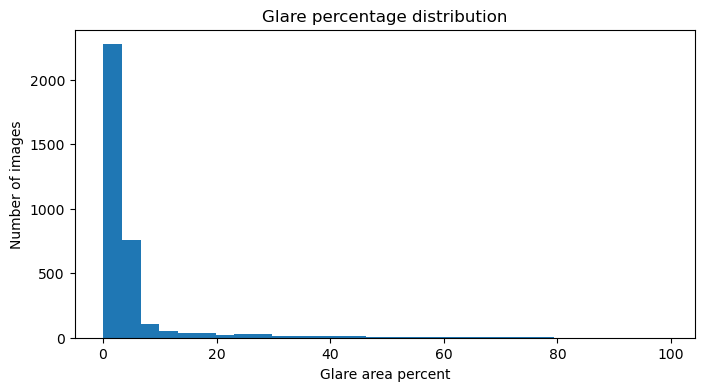

In [5]:
summary = report_df.groupby(["method_used", "status"], dropna=False).size().reset_index(name="count")
display(summary)

if len(report_df) > 0 and "glare_area_percent" in report_df:
    numeric_glare = pd.to_numeric(report_df["glare_area_percent"], errors="coerce")
    print("Mean glare %:", numeric_glare.mean())
    print("Median glare %:", numeric_glare.median())
    print("Max glare %:", numeric_glare.max())

    plt.figure(figsize=(8, 4))
    plt.hist(numeric_glare.dropna(), bins=30)
    plt.xlabel("Glare area percent")
    plt.ylabel("Number of images")
    plt.title("Glare percentage distribution")
    plt.show()


## 5. Create review contact sheet

This helps you quickly check whether the processing looks natural.


In [6]:
def make_contact_sheet_from_previews(preview_dir: Path, out_path: Path, max_images=60, thumb_width=500):
    preview_paths = sorted(preview_dir.glob("*_preview.png"))[:max_images]
    if not preview_paths:
        print("No previews found.")
        return None

    thumbs = []
    for p in preview_paths:
        img = Image.open(p).convert("RGB")
        ratio = thumb_width / img.width
        img = img.resize((thumb_width, int(img.height * ratio)))
        thumbs.append((p.name, img))

    cols = 2
    rows = int(np.ceil(len(thumbs) / cols))
    pad = 20
    label_h = 24
    cell_w = thumb_width + pad
    cell_h = max(img.height for _, img in thumbs) + label_h + pad

    sheet = Image.new("RGB", (cols * cell_w + pad, rows * cell_h + pad), "white")
    draw = ImageDraw.Draw(sheet)

    for idx, (name, img) in enumerate(thumbs):
        r = idx // cols
        c = idx % cols
        x = pad + c * cell_w
        y = pad + r * cell_h
        draw.text((x, y), name[:70], fill=(0, 0, 0))
        sheet.paste(img, (x, y + label_h))

    sheet.save(out_path)
    print("Contact sheet saved to:", out_path)
    return out_path

if MAKE_CONTACT_SHEET:
    contact_path = OUTPUT_DIR / "reflection_review_contact_sheet.png"
    make_contact_sheet_from_previews(PREVIEW_DIR, contact_path, CONTACT_SHEET_MAX_IMAGES)


Contact sheet saved to: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/glare/usable_nail_crops_roi102_flat_images_brightened_reflection_removed_output/reflection_review_contact_sheet.png


## 6. Optional: copy only safe processed images

This creates a folder containing only images with status:
- `ok_no_glare`
- `ok`
- `warning_large_glare_softened`

It excludes images marked as `unusable_too_much_glare`.


In [7]:
SAFE_DIR = OUTPUT_DIR / "safe_for_training_png"
SAFE_DIR.mkdir(parents=True, exist_ok=True)

safe_statuses = {"ok_no_glare", "ok", "warning_large_glare_softened"}

safe_count = 0
for _, row in report_df.iterrows():
    if row["status"] in safe_statuses and row["processed_path"]:
        src = Path(row["processed_path"])
        if src.exists():
            shutil.copy2(src, SAFE_DIR / src.name)
            safe_count += 1

print(f"Copied {safe_count} safe images to:", SAFE_DIR)


Copied 3212 safe images to: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/glare/usable_nail_crops_roi102_flat_images_brightened_reflection_removed_output/safe_for_training_png


## 7. How to judge results

Good result:
- glare is less visible
- nail color still looks natural
- nail edges are unchanged
- image size is unchanged
- no fake-looking smears across the whole nail

Bad result:
- nail becomes gray or plastic-looking
- color changes too much
- texture is smeared everywhere
- many images are marked `soften` even with tiny glare

Recommended first review:
1. Open `reflection_review_contact_sheet.png`
2. Sort `reflection_report.csv` by `glare_area_percent`
3. Manually inspect high-glare images first
